# Store revenue forecasting: package walkthrough

This short notebook exercises the same package, configuration, artifact, and scoring contracts used by the command-line workflow. It uses deterministic synthetic data so it runs quickly and never presents demo metrics as business results.

The original portfolio notebook remains available as `Store_Level_Revenue_Forecasting_and_Scenario_Planning.ipynb`. This walkthrough is the clean operational companion.

## The forecast contract

The model predicts one store for one future day. Before scoring day `t`, actual sales through day `t-1` must be available. Rolling demand features apply `shift(1)`, customer count is excluded, and multi-day forecasts require a separate recursive or direct-horizon design.

In [1]:
from pathlib import Path
import tempfile

import pandas as pd
import yaml
from IPython.display import Image, display

from store_revenue_forecasting.pipeline import run_pipeline
from store_revenue_forecasting.scoring import score_future_plan

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('C:/Users/pandy/AppData/Local/Temp/claude/C--Users-pandy/342386e3-6d53-41cd-bf20-fbbb41f391e8/scratchpad/ds-repo/End to end data science project/store-level-revenue-forecasting')

## Run the complete sample pipeline

Outputs go to a temporary directory, so executing this notebook does not overwrite the checked-in full-data figures or local model artifacts.

In [2]:
temporary = tempfile.TemporaryDirectory()
run_root = Path(temporary.name)

config = yaml.safe_load((PROJECT_ROOT / "config.sample.yaml").read_text(encoding="utf-8"))
config["project_root"] = str(PROJECT_ROOT)
config["paths"] = {
    "processed": str(run_root / "processed"),
    "models": str(run_root / "models"),
    "metrics": str(run_root / "metrics"),
    "tables": str(run_root / "tables"),
    "figures": str(run_root / "figures"),
}
temporary_config = run_root / "config.yaml"
temporary_config.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")

artifacts = run_pipeline(temporary_config)
sorted(artifacts)

['daily_holdout_figure',
 'day_of_week_error',
 'feature_importance',
 'holdout_predictions',
 'model',
 'model_comparison_figure',
 'model_performance',
 'monitoring_baseline',
 'promotion_error',
 'run_metadata',
 'scenario_daily',
 'scenario_impact_figure',
 'scenario_summary',
 'store_error']

## Inspect measured outputs

The sample exists to prove that the pipeline works. The README reports the separate full Rossmann run used for portfolio conclusions.

,Model,RMSE,MAE,WAPE,Forecast Bias,R2
0,Naive recent-demand average,1901.9150,1184.2188,0.2099,0.0110,0.1804
1,Linear Regression,336.0413,261.6716,0.0464,-0.0160,0.9744
2,Random Forest (sample smoke test),272.3039,210.4788,0.0373,0.0108,0.9832


,Scenario,Forecasted Revenue,vs Baseline,% Change
0,Baseline,718450.5474,0.0000,0.0000
1,No Promotions,684508.7780,-33941.7694,-0.0472
2,Full Promotions,907846.5206,189395.9732,0.2636
3,Demand Drop -15%,682097.6494,-36352.8980,-0.0506


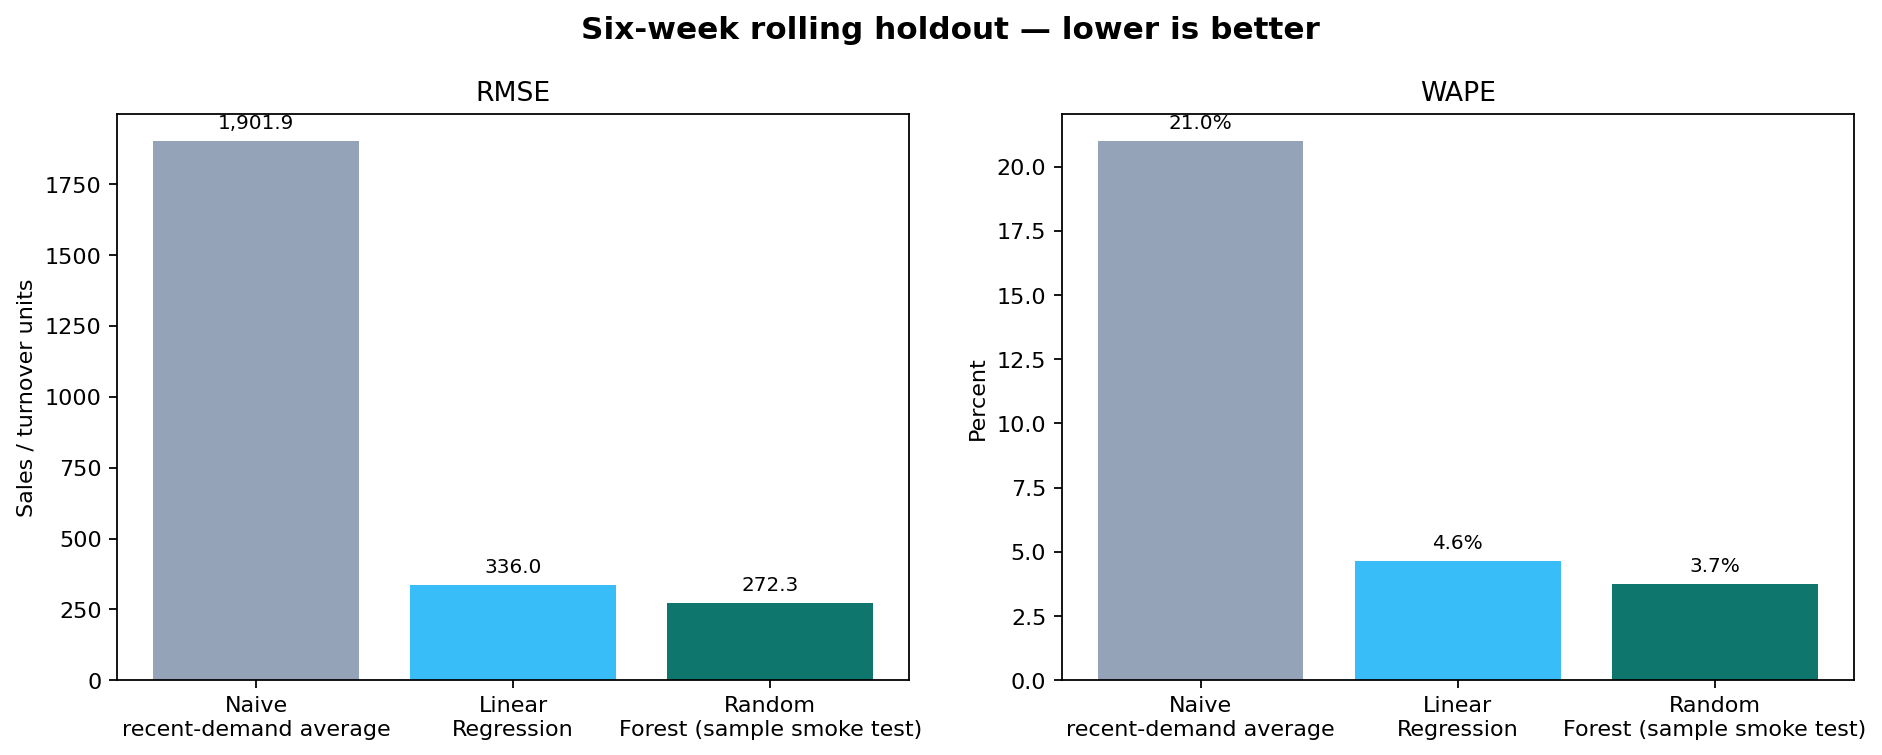

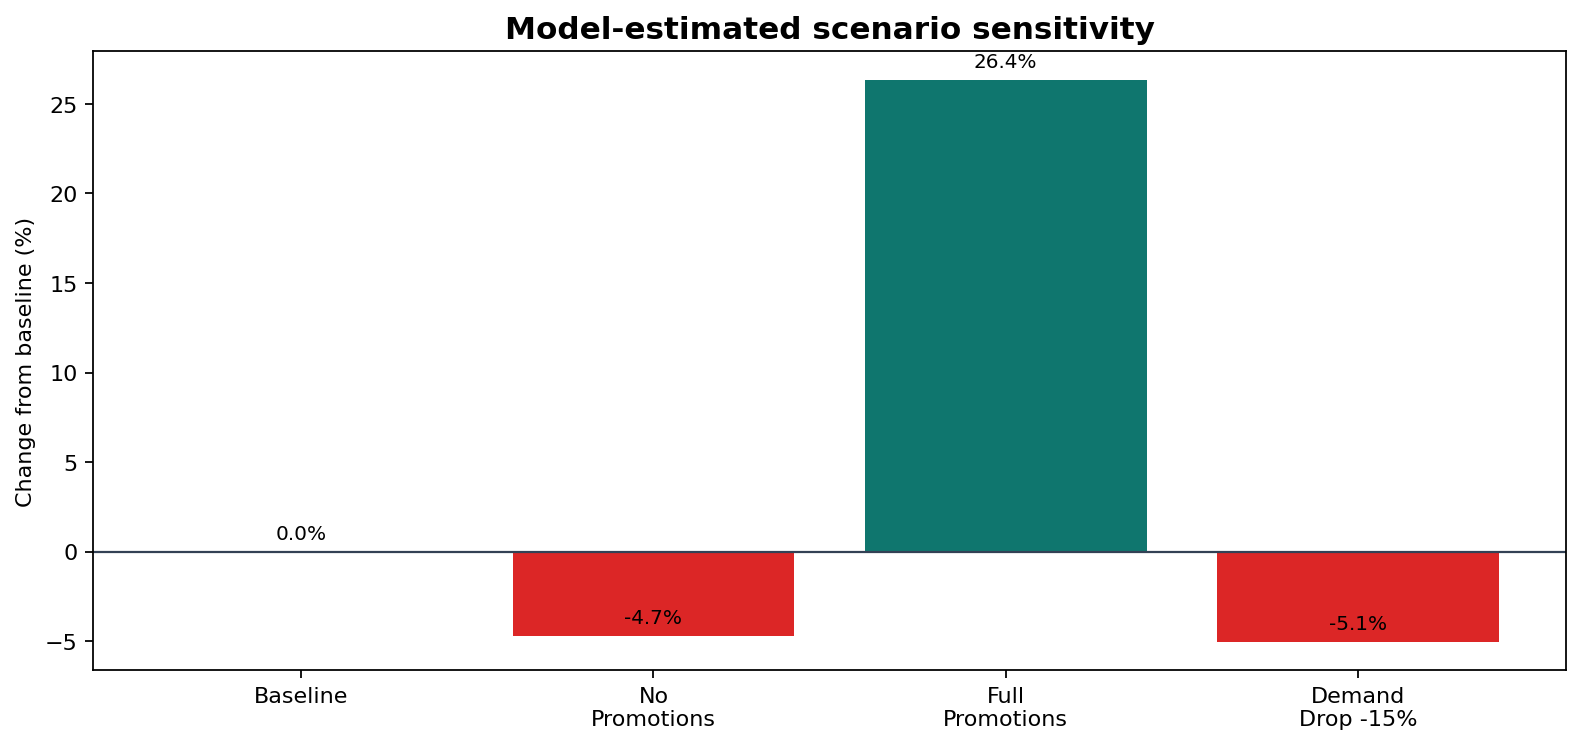

In [3]:
model_performance = pd.read_csv(artifacts["model_performance"])
scenario_summary = pd.read_csv(artifacts["scenario_summary"])

display(model_performance.round(4))
display(scenario_summary.round(4))
display(Image(filename=str(artifacts["model_comparison_figure"])))
display(Image(filename=str(artifacts["scenario_impact_figure"])))

## Score the next operating day

The scoring interface combines the saved model, actual history, store metadata, and one future operating-plan CSV. It rejects multiple forecast dates because version 1 is intentionally one-day-ahead.

In [4]:
scored = score_future_plan(
    model_path=artifacts["model"],
    history_path=PROJECT_ROOT / "data/sample/train.csv",
    future_path=PROJECT_ROOT / "data/sample/future.csv",
    store_path=PROJECT_ROOT / "data/sample/store.csv",
    lag_windows=config["features"]["lag_windows"],
    output_path=run_root / "processed/future_predictions.csv",
)

display(scored)
temporary.cleanup()

,Date,Store,PredictedSales
0,2024-05-20,1,4734.910606
1,2024-05-20,2,7514.725388
2,2024-05-20,3,5636.011523
3,2024-05-20,4,8249.162135
4,2024-05-20,5,6415.057430
5,2024-05-20,6,8844.346548


## What this demonstration does not prove

- Synthetic data does not establish forecast quality.
- Promotion scenarios are model sensitivities, not causal ROI.
- A rolling one-day-ahead holdout is not a one-shot six-week forecast.
- Production use still needs an approved source, scheduled monitoring, prediction intervals, and a rollback owner.

Those boundaries are part of the project, not footnotes added after the model was built.